# Gaussian Discriminant Analysis — An Illustrated Tour

> **GDA** is the *generative* cousin of logistic regression. Model each class as a Gaussian in feature space, then use Bayes' rule to classify.

$$p(x \mid y = k) = \mathcal{N}(x \mid \mu_k, \Sigma_k), \qquad p(y = k \mid x) \propto p(x \mid y) \,p(y).$$

---

**What we cover:**
- LDA — shared covariance → **linear** boundary
- QDA — per-class covariance → **quadratic** boundary
- Closed-form ML estimates of $\mu_k$, $\Sigma_k$, $\pi_k$
- Side-by-side with logistic regression
- When generative beats discriminative (and vice versa)

## The picture — one Gaussian per class, decision boundary where densities cross

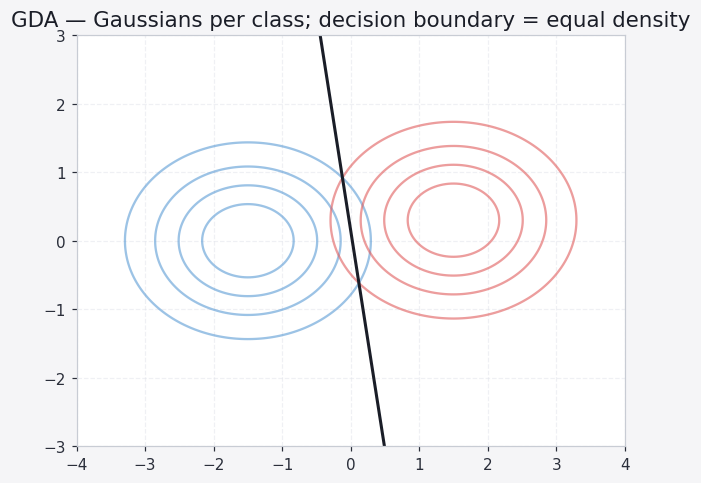

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
xx, yy = np.meshgrid(np.linspace(-4, 4, 200), np.linspace(-3, 3, 200))
def g(mx, my, sx, sy): return np.exp(-((xx-mx)**2/(2*sx**2)+(yy-my)**2/(2*sy**2)))
A = g(-1.5, 0, 1.0, 0.8); B = g(1.5, 0.3, 1.0, 0.8)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.contour(xx, yy, A, levels=4, colors=P[0], alpha=0.6)
ax.contour(xx, yy, B, levels=4, colors=P[1], alpha=0.6)
ax.contour(xx, yy, A-B, levels=[0], colors=['#1a1d27'], linewidths=2)
ax.set_title('GDA — Gaussians per class; decision boundary = equal density')
ax.set_aspect('equal'); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'

rng = np.random.default_rng(0)
# Equal-covariance set (LDA-friendly)
S_shared = np.array([[1.0, 0.4], [0.4, 0.6]])
X0a = rng.multivariate_normal([-1.5,  0.0], S_shared, 200)
X1a = rng.multivariate_normal([ 1.8,  0.5], S_shared, 200)
Xa = np.vstack([X0a, X1a]); ya = np.r_[np.zeros(200), np.ones(200)].astype(int)
# Different-covariance set (QDA-friendly)
S0 = np.array([[2.0, 0.0], [0.0, 0.4]])
S1 = np.array([[0.4, 0.0], [0.0, 2.0]])
X0b = rng.multivariate_normal([-0.5, 0.0], S0, 200)
X1b = rng.multivariate_normal([ 1.5, 1.0], S1, 200)
Xb = np.vstack([X0b, X1b]); yb = np.r_[np.zeros(200), np.ones(200)].astype(int)

---
## Closed-Form ML Estimates

$$\hat\pi_k = \frac{n_k}{n}, \qquad \hat\mu_k = \frac{1}{n_k}\sum_{i: y_i = k} x_i,$$

$$\hat\Sigma_k = \frac{1}{n_k}\sum_{i: y_i = k} (x_i - \hat\mu_k)(x_i - \hat\mu_k)^T \quad (\text{QDA}),$$

$$\hat\Sigma = \frac{1}{n}\sum_{k}\sum_{i: y_i = k} (x_i - \hat\mu_k)(x_i - \hat\mu_k)^T \quad (\text{LDA, shared}).$$

The decision boundary $\bigl\{x \,:\, p(y{=}1\mid x) = 0.5\bigr\}$ is **linear** when $\Sigma_0 = \Sigma_1$ (the quadratic terms cancel) and **quadratic** otherwise.

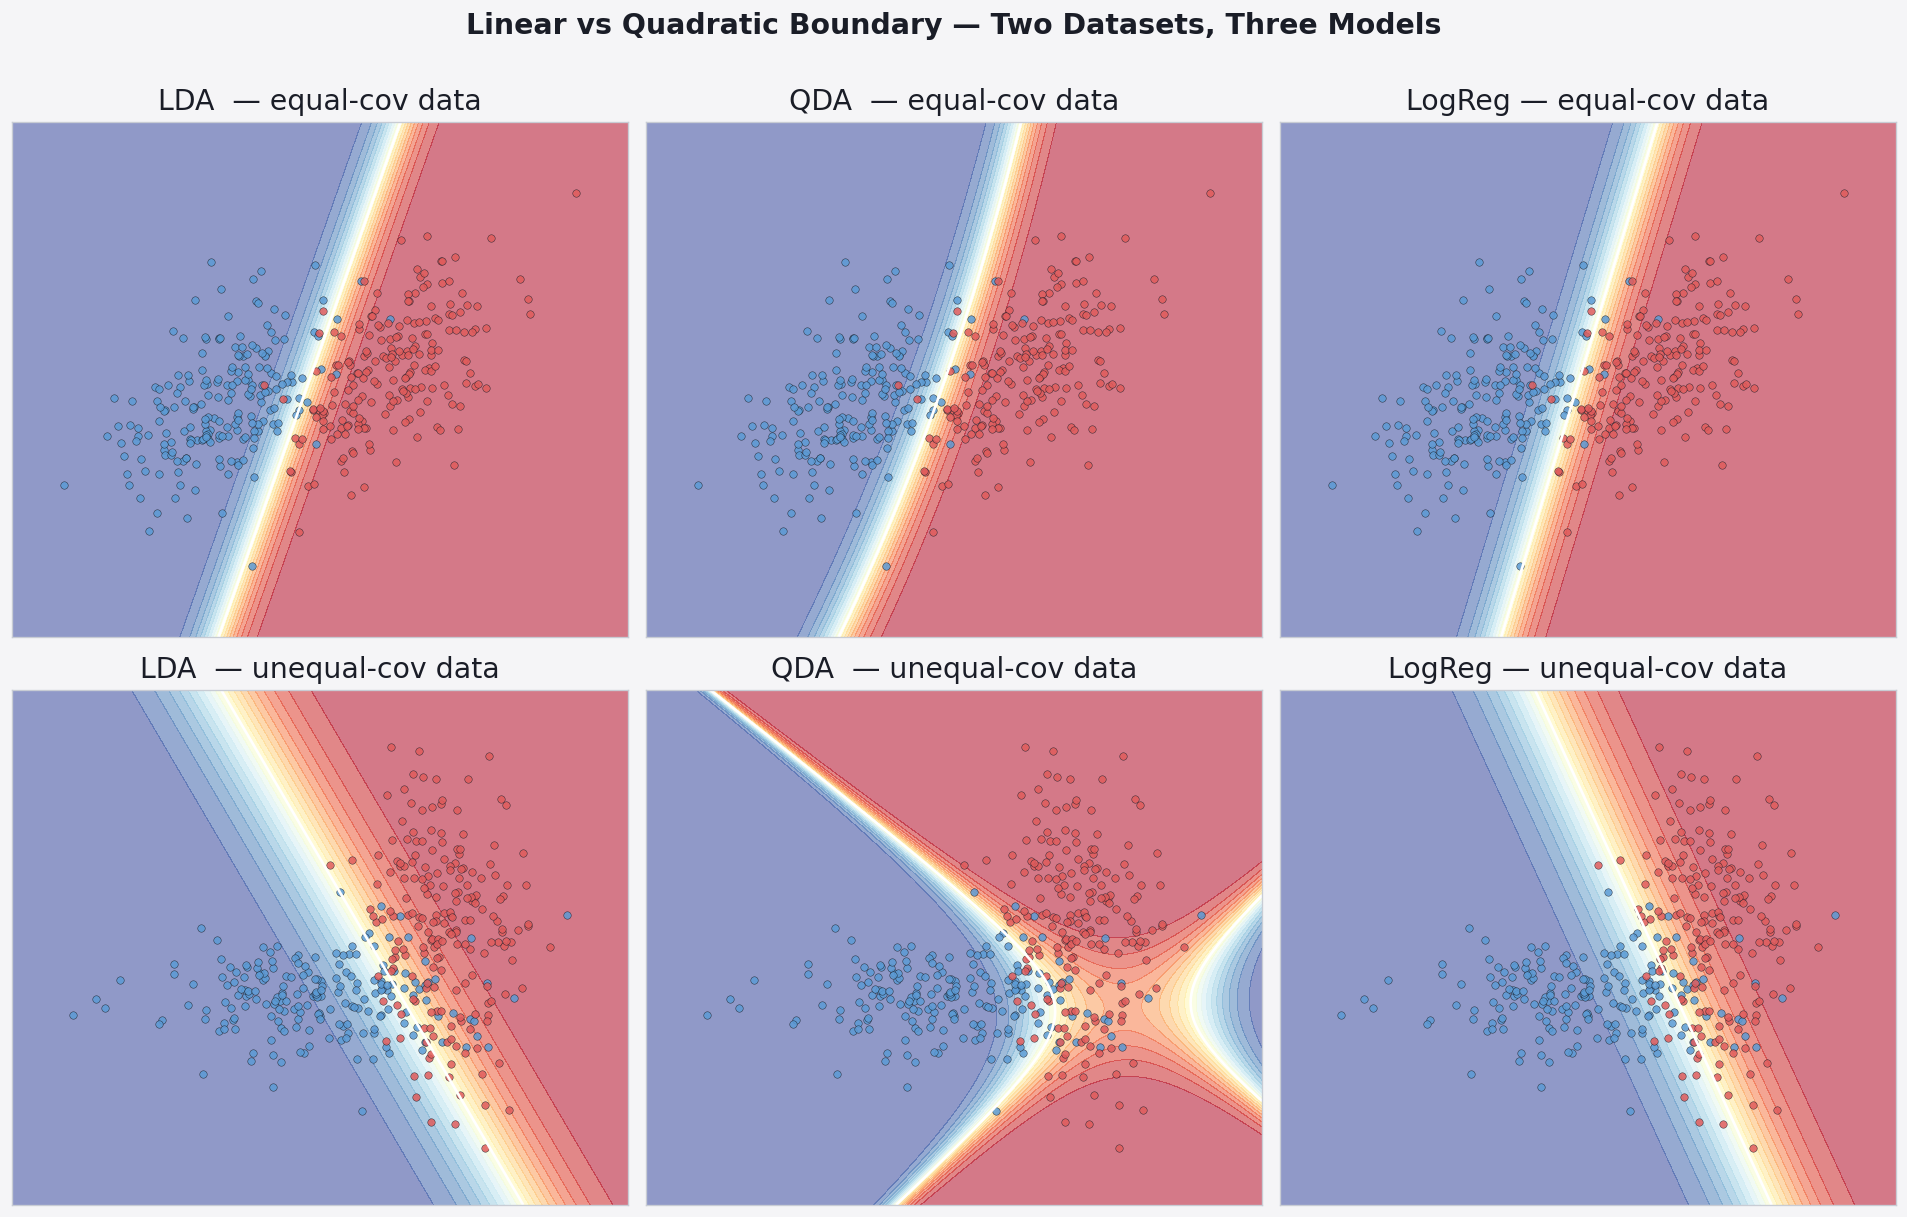

In [3]:
def draw_ellipse(ax, mean, cov, color):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]; vals = vals[order]; vecs = vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    for nstd in [1, 2]:
        w, h = 2 * nstd * np.sqrt(vals)
        ax.add_patch(Ellipse(xy=mean, width=w, height=h, angle=angle,
                              facecolor='none', edgecolor=color, lw=1.6, alpha=0.9 / nstd))

def panel(ax, X, y, model, title):
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
                          np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300))
    p = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
    ax.contourf(xx, yy, p, levels=20, cmap='RdYlBu_r', alpha=0.55)
    ax.contour(xx, yy, p, levels=[0.5], colors='#ffffff', linewidths=1.6)
    ax.scatter(X[y==0,0], X[y==0,1], c=C0, s=20, edgecolors='#1a1d27', lw=0.3, alpha=0.85)
    ax.scatter(X[y==1,0], X[y==1,1], c=C1, s=20, edgecolors='#1a1d27', lw=0.3, alpha=0.85)
    ax.set_title(title, pad=8); ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
panel(axes[0,0], Xa, ya, LinearDiscriminantAnalysis(),    'LDA  — equal-cov data')
panel(axes[0,1], Xa, ya, QuadraticDiscriminantAnalysis(), 'QDA  — equal-cov data')
panel(axes[0,2], Xa, ya, LogisticRegression(max_iter=1000), 'LogReg — equal-cov data')
panel(axes[1,0], Xb, yb, LinearDiscriminantAnalysis(),    'LDA  — unequal-cov data')
panel(axes[1,1], Xb, yb, QuadraticDiscriminantAnalysis(), 'QDA  — unequal-cov data')
panel(axes[1,2], Xb, yb, LogisticRegression(max_iter=1000), 'LogReg — unequal-cov data')
fig.suptitle('Linear vs Quadratic Boundary — Two Datasets, Three Models', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Visualising the Fitted Gaussians

QDA estimates one ellipse per class. On the unequal-covariance data, those ellipses point in different directions — hence the curved boundary.

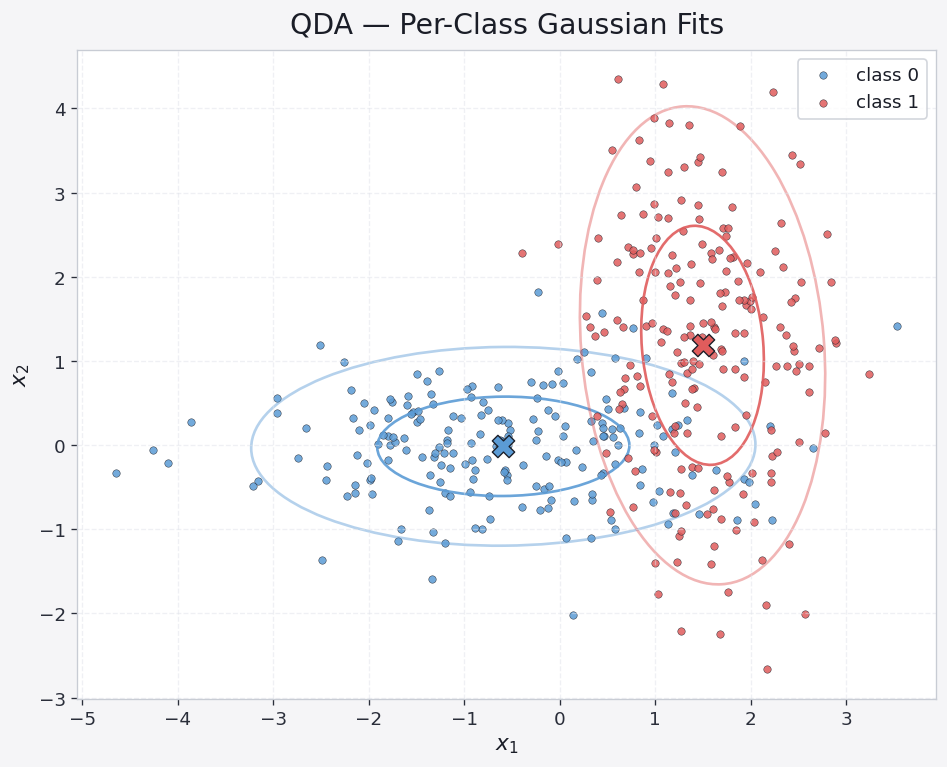

In [4]:
qda = QuadraticDiscriminantAnalysis(store_covariance=True).fit(Xb, yb)
fig, ax = plt.subplots(figsize=(8, 6.5))
for k, color in zip([0, 1], [C0, C1]):
    m = yb == k
    ax.scatter(Xb[m,0], Xb[m,1], c=color, s=20, edgecolors='#1a1d27', lw=0.3, alpha=0.85, label=f'class {k}')
    draw_ellipse(ax, qda.means_[k], qda.covariance_[k], color)
    ax.scatter(*qda.means_[k], s=180, c=color, marker='X', edgecolors='#1a1d27', lw=0.8, zorder=6)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.legend()
ax.set_title('QDA — Per-Class Gaussian Fits', pad=10); ax.grid(True)
plt.tight_layout(); plt.show()

---
## Generative vs Discriminative

When the Gaussian assumption is **correct**, GDA is the most efficient classifier and beats logistic regression for small $n$.
When the assumption is **wrong**, logistic regression typically wins because it directly fits $p(y \mid x)$ without committing to a story about $p(x)$.

---
## ⚖️ When to use GDA — and when not to

| Situation | LDA | QDA | Logistic | Naive Bayes |
|---|---|---|---|---|
| Classes Gaussian, equal cov | ✅ best | suboptimal | ✅ | ❌ |
| Classes Gaussian, unequal cov | ❌ | ✅ best | partial | ❌ |
| Tiny $n$, high $d$ | ✅ regularised | ❌ unstable | partial | ✅ |
| Features clearly non-Gaussian | ❌ | ❌ | ✅ | ✅ |

> Reach for GDA when you genuinely believe the **conditional density** is Gaussian. With enough data, logistic regression matches it without the assumption.


---
## 🎯 Try this

1. **Misspecify the prior.** Set $\hat\pi$ to wrong class proportions (e.g. 0.9 / 0.1 on balanced data) — watch the boundary shift toward the under-weighted class.
2. **Tied vs untied $\Sigma$.** Compare LDA and QDA on data drawn from genuinely shared and unshared covariances. The wrong assumption hurts visibly.
3. **Generative sample.** After fitting, draw $x \sim \mathcal{N}(\hat\mu_k, \hat\Sigma_k)$ for each class and overlay on the training scatter — a visual sanity check.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Generative model | $p(x \mid y) \,p(y)$ | Models the data, not just the label |
| LDA | Shared $\Sigma$ | Linear boundary; same as logistic *a posteriori* |
| QDA | Per-class $\Sigma_k$ | Quadratic boundary; more flexible |
| ML estimates | Closed form | No optimisation needed |
| Strength | Tiny on small data, calibrated probabilities, multi-class for free | Great when classes really are Gaussian-ish |
| Weakness | Wrong if $p(x \mid y)$ is far from Gaussian; $O(d^2)$ params per class for QDA | Use logistic / SVM / trees if shape is weird |

**Bottom line:** GDA is **logistic regression's generative twin**. Picking LDA vs QDA vs LogReg comes down to how strongly you believe the Gaussian story — generative models pay off when their assumptions hold.